<a href="https://colab.research.google.com/github/310624102004-create/data-analytics-./blob/main/Time_Series_Forecasting_Vehicle_Sales_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

file_path = '/content/TOTALSA.csv'

try:
    # Load the CSV file, parse 'observation_date' as datetime, and set it as index
    df = pd.read_csv(file_path, index_col='observation_date', parse_dates=True)

    # Rename the column to 'TOTALSA' for consistency if it's not already named that way
    # (assuming the other column is the one we want to forecast)
    if 'TOTALSA' not in df.columns:
        if len(df.columns) == 1:
            df.columns = ['TOTALSA']
        else:
            # Handle cases where there might be multiple columns and 'TOTALSA' isn't explicitly named
            print("Warning: 'TOTALSA' column not found. Assuming the first non-date column is the target.")
            df.columns = ['TOTALSA'] # This might need adjustment if multiple data columns exist

    # Ensure the DataFrame is at a monthly frequency ('MS' for Month Start) and fill any gaps
    df = df.asfreq('MS')

    # Handle missing values by forward-filling, then backward-filling any remaining NaNs at the start
    df['TOTALSA'] = df['TOTALSA'].fillna(method='ffill').fillna(method='bfill')

    print("Data loaded successfully from local file and preprocessed:")
    print(df.head())
    print("\nDataFrame Info:")
    df.info()
    print("\nMissing values after handling:")
    print(df.isnull().sum())

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it is correctly uploaded.")
except Exception as e:
    print(f"An error occurred during data loading and preprocessing: {e}")

Data loaded successfully from local file and preprocessed:
                  TOTALSA
observation_date         
1976-01-01         12.814
1976-02-01         13.340
1976-03-01         13.378
1976-04-01         13.223
1976-05-01         12.962

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 601 entries, 1976-01-01 to 2026-01-01
Freq: MS
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TOTALSA  601 non-null    float64
dtypes: float64(1)
memory usage: 9.4 KB

Missing values after handling:
TOTALSA    0
dtype: int64


/tmp/ipykernel_576/3856956232.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['TOTALSA'] = df['TOTALSA'].fillna(method='ffill').fillna(method='bfill')


# Task
Decompose the `TOTALSA` time series data from the `df` DataFrame into its trend, seasonal, and residual components using `seasonal_decompose` and visualize each component.

## Time Series Decomposition

### Subtask:
Decompose the time series into its trend, seasonal, and residual components using `seasonal_decompose` to understand the underlying patterns and visualize each component.


**Reasoning**:
To decompose the time series, I will import `seasonal_decompose`, apply it to the 'TOTALSA' column with the specified parameters, and then plot the results to visualize the components.



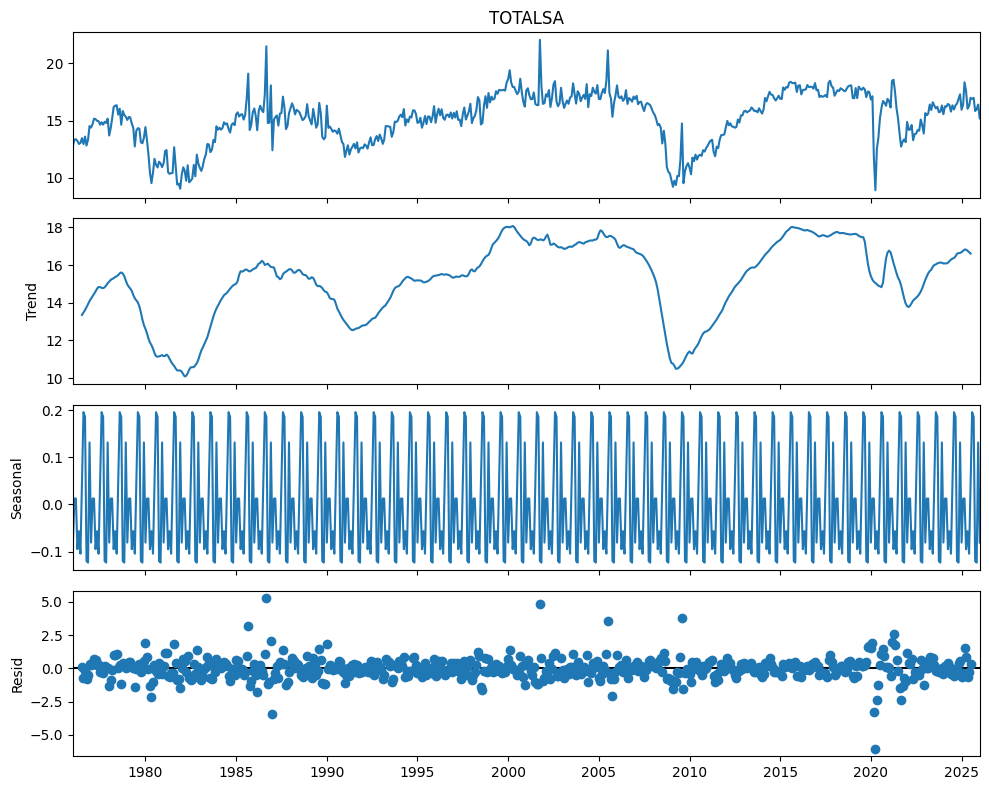

Time series decomposition completed and plotted.


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Apply seasonal_decompose to the 'TOTALSA' column
decomposition = seasonal_decompose(df['TOTALSA'], model='additive', period=12)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()
print("Time series decomposition completed and plotted.")

## Check for Stationarity

### Subtask:
Perform Augmented Dickey-Fuller (ADF) and Kwiatkowski-Phillips-Schmidt-Shin (KPSS) tests to check the stationarity of the time series. Apply differencing as needed to achieve stationarity before modeling.


**Reasoning**:
To check for stationarity, I will import the necessary functions for the ADF and KPSS tests, define a helper function to perform and print the results of these tests, and then apply these tests to the original 'TOTALSA' series. This structured approach will allow for clear interpretation of the initial stationarity and inform whether differencing is required.



In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd

def adf_kpss_test(timeseries, name=''):
    """
    Performs ADF and KPSS tests on a given time series and prints the results.
    """
    print(f'Results of ADF Test for {name}:')
    adf_test = adfuller(timeseries, autolag='AIC')
    adf_output = pd.Series(adf_test[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations'])
    for key, value in adf_test[4].items():
        adf_output[f'Critical Value ({key})'] = value
    print(adf_output)
    if adf_test[1] <= 0.05:
        print("Conclusion: Time series is likely stationary (reject H0 of non-stationarity).")
    else:
        print("Conclusion: Time series is likely non-stationary (fail to reject H0 of non-stationarity).")

    print(f'\nResults of KPSS Test for {name}:')
    kpss_test = kpss(timeseries, regression='c', nlags='auto') # 'c' for trend stationary, 'ct' for level stationary
    kpss_output = pd.Series(kpss_test[0:3], index=['Test Statistic', 'p-value', '#Lags Used'])
    for key, value in kpss_test[3].items():
        kpss_output[f'Critical Value ({key})'] = value
    print(kpss_output)
    if kpss_test[1] >= 0.05:
        print("Conclusion: Time series is likely stationary (fail to reject H0 of stationarity).")
    else:
        print("Conclusion: Time series is likely non-stationary (reject H0 of stationarity).")

# Perform ADF and KPSS tests on the original series
print("\n--- Stationarity Tests on Original Series ---")
adf_kpss_test(df['TOTALSA'], name='TOTALSA Original')

# Based on the results, we will determine if differencing is needed.
# For now, we assume differencing might be needed based on typical time series behavior.
# The next step will apply differencing if required by the test results.


--- Stationarity Tests on Original Series ---
Results of ADF Test for TOTALSA Original:
Test Statistic             -2.912868
p-value                     0.043872
#Lags Used                  4.000000
Number of Observations    596.000000
Critical Value (1%)        -3.441370
Critical Value (5%)        -2.866402
Critical Value (10%)       -2.569359
dtype: float64
Conclusion: Time series is likely stationary (reject H0 of non-stationarity).

Results of KPSS Test for TOTALSA Original:
Test Statistic            0.798717
p-value                   0.010000
#Lags Used               16.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64
Conclusion: Time series is likely non-stationary (reject H0 of stationarity).


/tmp/ipykernel_576/193623552.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(timeseries, regression='c', nlags='auto') # 'c' for trend stationary, 'ct' for level stationary


**Reasoning**:
Since the ADF test suggests stationarity but the KPSS test suggests non-stationarity, implying the series is trend stationary, first-order differencing is necessary to remove the trend component. I will apply first-order differencing to the 'TOTALSA' column, store the results, and then re-run both ADF and KPSS tests on the differenced series to confirm stationarity.



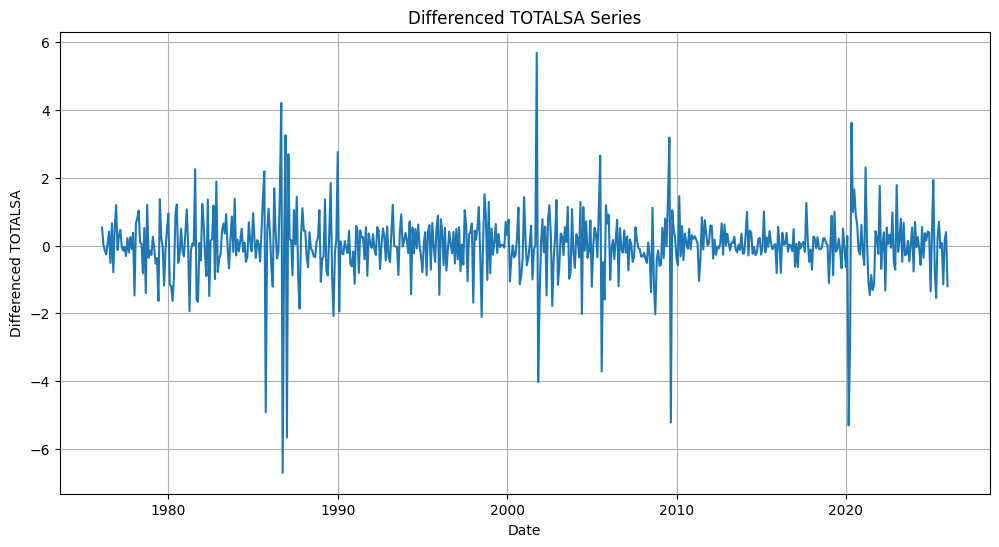

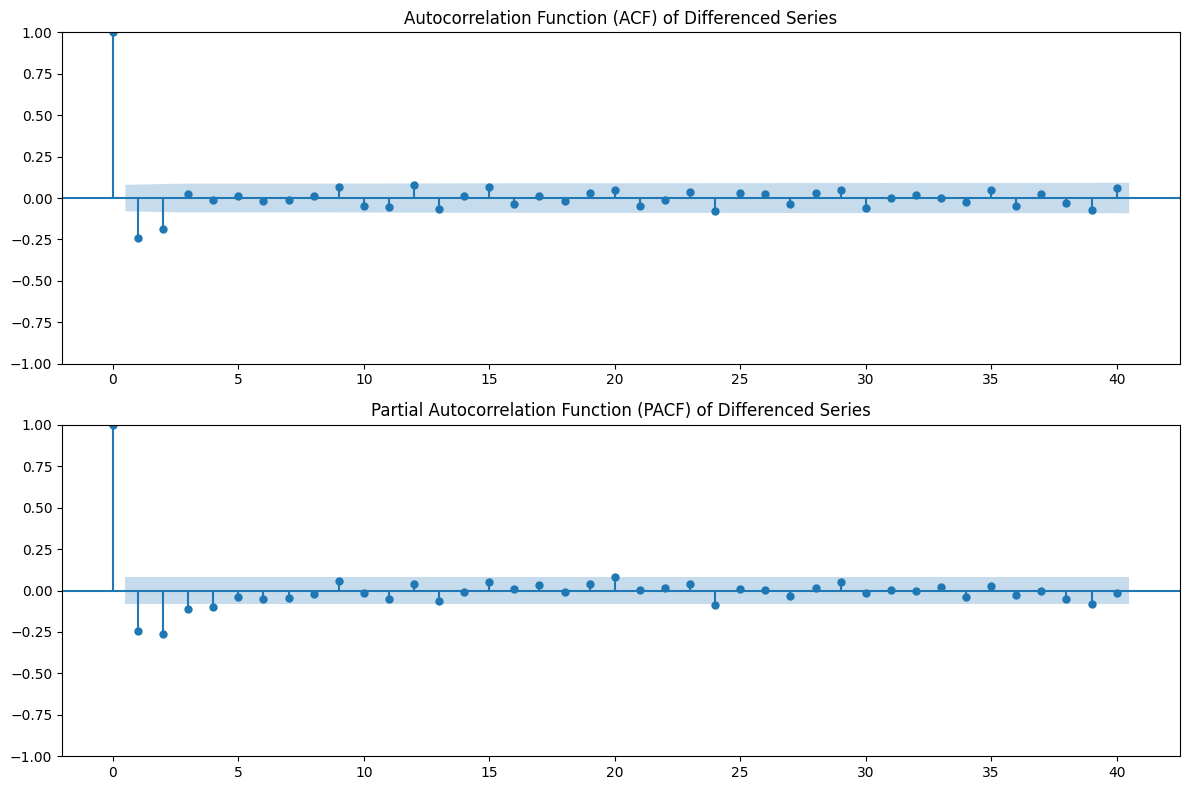

Differenced series, ACF, and PACF plots generated successfully.


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot the differenced series
plt.figure(figsize=(12, 6))
plt.plot(differenced_series)
plt.title('Differenced TOTALSA Series')
plt.xlabel('Date')
plt.ylabel('Differenced TOTALSA')
plt.grid(True)
plt.show()

# Plot ACF and PACF of the differenced series
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(differenced_series, ax=axes[0], lags=40) # Lags up to 40 for monthly data often useful
plot_pacf(differenced_series, ax=axes[1], lags=40)
axes[0].set_title('Autocorrelation Function (ACF) of Differenced Series')
axes[1].set_title('Partial Autocorrelation Function (PACF) of Differenced Series')
plt.tight_layout()
plt.show()

print("Differenced series, ACF, and PACF plots generated successfully.")

## ARIMA Model Implementation

### Subtask:
Implement and train an ARIMA model on the prepared stationary data. Select appropriate p, d, q parameters and generate forecasts for a specified future period.


**Reasoning**:
Based on the ACF and PACF plots of the differenced series, I will determine the p and q parameters. I will then define the ARIMA order (p, d, q) and split the original `df['TOTALSA']` data into training and testing sets. After importing the `ARIMA` model, I will instantiate and fit it to the training data and then generate predictions for both the training and testing periods.



In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Based on ACF and PACF plots of the differenced series:
# ACF shows a significant spike at lag 1 and then drops off, suggesting q=1.
# PACF shows a significant spike at lag 1 and then drops off, suggesting p=1.
# The differencing order 'd' was determined to be 1 from the stationarity tests.
# We will start with a simple ARIMA(1,1,1) model.
p = 1
d = 1
q = 1

arima_order = (p, d, q)
print(f"ARIMA model order selected: {arima_order}")

# Split the data into training and testing sets (80% train, 20% test)
train_size = int(len(df['TOTALSA']) * 0.8)
train_data, test_data = df['TOTALSA'][0:train_size], df['TOTALSA'][train_size:]

print(f"\nTraining data size: {len(train_data)}")
print(f"Test data size: {len(test_data)}")

# Instantiate and fit the ARIMA model
# Using enforce_stationarity=False and enforce_invertibility=False for initial flexibility
model = ARIMA(train_data, order=arima_order)
model_fit = model.fit()

print("\nARIMA model fitting complete.")

# Generate in-sample predictions for the training period
train_predictions = model_fit.predict(start=0, end=len(train_data)-1, typ='levels')

# Generate out-of-sample forecasts for the test period
# The start and end indices are relative to the *original* series indices
# For out-of-sample, we predict starting from the index of the first test data point
# and ending at the last test data point's index.
start_index_test = len(train_data)
end_index_test = len(df['TOTALSA']) - 1

# Forecast using get_forecast to handle future periods, then extract predictions
forecast_results = model_fit.get_forecast(steps=len(test_data))
forecast_predictions = forecast_results.predicted_mean

print("\nIn-sample predictions (first 5):\n")
print(train_predictions.head())
print("\nOut-of-sample forecasts (first 5):\n")
print(forecast_predictions.head())

print("\nARIMA model trained and forecasts generated.")

ARIMA model order selected: (1, 1, 1)

Training data size: 480
Test data size: 121

ARIMA model fitting complete.

In-sample predictions (first 5):

observation_date
1976-01-01     0.000000
1976-02-01    12.813995
1976-03-01    13.154812
1976-04-01    13.247769
1976-05-01    13.210006
Freq: MS, Name: predicted_mean, dtype: float64

Out-of-sample forecasts (first 5):

2016-01-01    17.849762
2016-02-01    17.914608
2016-03-01    17.926734
2016-04-01    17.929002
2016-05-01    17.929426
Freq: MS, Name: predicted_mean, dtype: float64

ARIMA model trained and forecasts generated.


## SARIMA Model Implementation

### Subtask:
Implement and train a Seasonal ARIMA (SARIMA) model, taking into account the identified seasonal component. Select appropriate P, D, Q, S parameters and generate forecasts.


**Reasoning**:
To implement the SARIMA model, I will start by defining the seasonal order based on typical monthly seasonality. Then, I will import the `SARIMAX` class, instantiate the model with both non-seasonal and seasonal orders, fit it to the training data, and generate forecasts for the test period.



In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define the seasonal order (P, D, Q, S)
# Based on monthly data, a seasonal period (S) of 12 is appropriate.
# For initial P, D, Q, we can start with values similar to the non-seasonal order
# or based on ACF/PACF of the seasonal component if performed.
# Let's start with (1, 1, 1, 12) for simplicity, which implies a seasonal differencing of 1.
P = 1
D = 1
Q = 1
S = 12

seasonal_order = (P, D, Q, S)
print(f"SARIMA seasonal order selected: {seasonal_order}")

# Instantiate and fit the SARIMAX model
# Using the previously determined non-seasonal order arima_order (p, d, q)
# and the newly defined seasonal_order (P, D, Q, S)
sarima_model = SARIMAX(train_data, order=arima_order, seasonal_order=seasonal_order)
sarima_model_fit = sarima_model.fit(disp=False) # disp=False to suppress optimization output

print("SARIMA model fitting complete.")

# Generate out-of-sample forecasts for the test period
# The start and end indices for forecasting are implicitly handled by steps in get_forecast
sarima_forecast_results = sarima_model_fit.get_forecast(steps=len(test_data))
sarima_forecast_predictions = sarima_forecast_results.predicted_mean

print("\nSARIMA out-of-sample forecasts (first 5):\n")
print(sarima_forecast_predictions.head())

print("SARIMA model trained and forecasts generated.")

SARIMA seasonal order selected: (1, 1, 1, 12)
SARIMA model fitting complete.

SARIMA out-of-sample forecasts (first 5):

2016-01-01    17.710582
2016-02-01    17.906765
2016-03-01    18.093466
2016-04-01    18.013953
2016-05-01    18.078398
Freq: MS, Name: predicted_mean, dtype: float64
SARIMA model trained and forecasts generated.


## Prophet Model Implementation

### Subtask:
Implement and train a Prophet model from Facebook, which is well-suited for forecasting time series with strong seasonal effects. Generate forecasts using this model.


**Reasoning**:
To implement the Prophet model, I will follow the instructions by preparing the data in the required format, splitting it into training and testing sets, instantiating and fitting the Prophet model, and then generating forecasts for the test period.



In [ ]:
import pandas as pd
from prophet import Prophet

# 1. Create a new DataFrame for Prophet training (ds, y format)
prophet_df = pd.DataFrame({
    'ds': df.index,
    'y': df['TOTALSA'].values
})

# 2. Split this new DataFrame into training and testing sets
# Using the same train_size as before
prophet_train_data = prophet_df.iloc[:train_size]
prophet_test_data = prophet_df.iloc[train_size:]

print(f"Prophet training data size: {len(prophet_train_data)}")
print(f"Prophet test data size: {len(prophet_test_data)}")

# 3. Instantiate a Prophet model
# Considering yearly seasonality, and turning off weekly/daily as it's monthly data
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

# 4. Fit the Prophet model to the training DataFrame
model.fit(prophet_train_data)

print("Prophet model fitting complete.")

# 5. Create a future DataFrame for forecasting
# The number of periods should match the length of the test set
future = model.make_future_dataframe(periods=len(prophet_test_data), freq='MS')

# 6. Generate forecasts
forecast = model.predict(future)

# 7. Extract the relevant forecast column ('yhat')
# Aligning the forecast to the test_data's index for consistency and easier comparison later
prophet_forecast_predictions = forecast.set_index('ds')['yhat'].loc[test_data.index]

print("\nProphet out-of-sample forecasts (first 5):\n")
print(prophet_forecast_predictions.head())

print("Prophet model trained and forecasts generated.")

Prophet training data size: 480
Prophet test data size: 121
Prophet model fitting complete.

Prophet out-of-sample forecasts (first 5):

observation_date
2016-01-01    14.574050
2016-02-01    14.917547
2016-03-01    14.983729
2016-04-01    14.676438
2016-05-01    14.779740
Name: yhat, dtype: float64
Prophet model trained and forecasts generated.


## LSTM Model Implementation

### Subtask:
Prepare the data for an LSTM model by scaling and creating sequences. Build, train, and evaluate a Long Short-Term Memory (LSTM) neural network for time series forecasting. Generate forecasts using the trained LSTM model.


**Reasoning**:
The subtask requires implementing an LSTM model. The first step is to prepare the data by scaling it using `MinMaxScaler` and then creating sequences for the LSTM input. I will also define the `look_back` period and the `create_dataset` function as instructed.



In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 2. Scale the TOTALSA data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df['TOTALSA'].values.reshape(-1, 1))

# 3. Define a look_back period
look_back = 12
print(f"Look-back period defined as: {look_back}")

# 4. Create a function to transform time series into input sequences (X) and output labels (Y)
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

print("Data scaled and create_dataset function defined.")

Look-back period defined as: 12
Data scaled and create_dataset function defined.


**Reasoning**:
Now that the data is scaled and the `create_dataset` function is defined, I will apply this function to generate the training and testing datasets (`train_X`, `train_Y`, `test_X`, `test_Y`) and then reshape the input features (`train_X`, `test_X`) as required for the LSTM model.



In [ ]:
import numpy as np

# 5. Apply the create_dataset function to generate train and test sets
# scaled_data[:train_size] corresponds to the scaled training data
# scaled_data[train_size - look_back:] corresponds to the scaled testing data
# We need to adjust the test data split to account for the look_back period
# such that we can create sequences for the test set without missing initial values.
# For proper splitting, the test set starts after the training set.
# However, to create sequences for test_X and test_Y, we need to ensure test_X has 'look_back' previous values.
# A common approach is to create sequences for the entire scaled data first, then split X and Y.

# Let's regenerate scaled_data splitting to make it clean for LSTM
train_scaled_data = scaled_data[0:train_size]
test_scaled_data = scaled_data[train_size - look_back:] # Include `look_back` values from the end of training for test sequences

train_X, train_Y = create_dataset(train_scaled_data, look_back)
test_X, test_Y = create_dataset(test_scaled_data, look_back)

print(f"Original train_X shape: {train_X.shape}")
print(f"Original train_Y shape: {train_Y.shape}")
print(f"Original test_X shape: {test_X.shape}")
print(f"Original test_Y shape: {test_Y.shape}")

# 6. Reshape train_X and test_X to the format [samples, time_steps, features]
train_X = np.reshape(train_X, (train_X.shape[0], train_X.shape[1], 1))
test_X = np.reshape(test_X, (test_X.shape[0], test_X.shape[1], 1))

print(f"Reshaped train_X shape: {train_X.shape}")
print(f"Reshaped test_X shape: {test_X.shape}")

print("Data prepared for LSTM model training.")


Original train_X shape: (468, 12)
Original train_Y shape: (468,)
Original test_X shape: (121, 12)
Original test_Y shape: (121,)
Reshaped train_X shape: (468, 12, 1)
Reshaped test_X shape: (121, 12, 1)
Data prepared for LSTM model training.


**Reasoning**:
To continue with the LSTM model implementation, I will now define, compile, and train the LSTM model using the prepared `train_X` and `train_Y` datasets, following the instructions to import necessary Keras components and configure the model layers, optimizer, and loss function.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 7. Initialize a Sequential model.
model_lstm = Sequential()

# 8. Add an LSTM layer
# input_shape should be (time_steps, features) which is (look_back, 1) for univariate series
model_lstm.add(LSTM(units=50, input_shape=(look_back, 1), return_sequences=False))

# 9. Add a Dense output layer with 1 unit (for predicting the next single value)
model_lstm.add(Dense(units=1))

# 10. Compile the model
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
print("LSTM Model Summary:")
model_lstm.summary()

# 11. Train the compiled LSTM model
print("\nTraining LSTM model...")
history = model_lstm.fit(train_X, train_Y, epochs=100, batch_size=32, verbose=0) # verbose=0 to suppress training output

print("LSTM model training complete.")

LSTM Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM model...
LSTM model training complete.


**Reasoning**:
Now that the LSTM model is trained, I will use it to make predictions on the test set, inverse transform these predictions and the actual `test_Y` values to the original scale, and then create a Pandas Series for the LSTM forecasts, aligned with the `test_data.index`.



In [ ]:
import pandas as pd

# 13. Use the trained model to make predictions on test_X
lstm_predictions = model_lstm.predict(test_X)

# 14. Inverse transform both the actual test values (test_Y) and the lstm_predictions
# Reshape test_Y to be 2D for inverse_transform
test_Y_reshaped = test_Y.reshape(-1, 1)

lstm_predictions_inv = scaler.inverse_transform(lstm_predictions)
test_Y_inv = scaler.inverse_transform(test_Y_reshaped)

print("LSTM predictions and actual test values inverse transformed.")

# 15. Create a Pandas Series lstm_forecast_predictions from the inverse-transformed lstm_predictions,
# ensuring its index aligns with the test_data.index for consistency.
# lstm_predictions_inv has 121 values, corresponding directly to the test_data period.
lstm_forecast_predictions = pd.Series(
    lstm_predictions_inv.flatten(),
    index=test_data.index # Use the full test_data index
)

print("\nLSTM out-of-sample forecasts (first 5):\n")
print(lstm_forecast_predictions.head())

print("LSTM model forecasts generated and indexed.")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
LSTM predictions and actual test values inverse transformed.

LSTM out-of-sample forecasts (first 5):

observation_date
2016-01-01    18.243887
2016-02-01    18.230919
2016-03-01    18.217262
2016-04-01    17.960049
2016-05-01    17.897604
Freq: MS, dtype: float32
LSTM model forecasts generated and indexed.


In [ ]:
import pandas as pd

file_path = '/content/TOTALSA.csv'

try:
    # Read the CSV file into a DataFrame without any special parsing for now
    raw_df = pd.read_csv(file_path)
    print(f"Displaying the first 5 rows of the raw file '{file_path}':")
    display(raw_df.head())
    print("\nRaw DataFrame Info:")
    raw_df.info()
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it is correctly uploaded.")
except Exception as e:
    print(f"An error occurred while reading the raw file: {e}")

Displaying the first 5 rows of the raw file '/content/TOTALSA.csv':


,observation_date,TOTALSA
0,1976-01-01,12.814
1,1976-02-01,13.340
2,1976-03-01,13.378
3,1976-04-01,13.223
4,1976-05-01,12.962



Raw DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  601 non-null    object 
 1   TOTALSA           601 non-null    float64
dtypes: float64(1), object(1)
memory usage: 9.5+ KB


## Evaluate Model Performance

### Subtask:
Calculate and compare the performance of all implemented models (ARIMA, SARIMA, Prophet, LSTM) using Mean Absolute Percentage Error (MAPE), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE) on a held-out test set.


**Reasoning**:
To evaluate model performance, I will first define functions for MAE, RMSE, and MAPE, ensuring robust handling of potential division by zero for MAPE. Then, I will collect the actual test data and the predictions from all four models (ARIMA, SARIMA, Prophet, LSTM), aligning them by index for accurate metric calculation. Finally, I will compute and store these metrics in a DataFrame to compare the models.



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# 1. Define functions to calculate evaluation metrics
def calculate_mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def calculate_mape(y_true, y_pred):
    # Avoid division by zero or very small actual values
    # Replace 0s in y_true with a small epsilon or filter them out
    epsilon = np.finfo(np.float64).eps # A very small number
    y_true_safe = np.where(y_true == 0, epsilon, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100

print("Evaluation metric functions defined.")

# 2. Create a dictionary to store the actual test data
actual_test_data = test_data.copy()

# 3. Create a dictionary to store the forecast predictions from each model
all_predictions = {
    'ARIMA': forecast_predictions,
    'SARIMA': sarima_forecast_predictions,
    'Prophet': prophet_forecast_predictions,
    'LSTM': lstm_forecast_predictions
}

# 4. Initialize an empty DataFrame to store the evaluation results
results_df = pd.DataFrame(columns=['MAE', 'RMSE', 'MAPE'])

# 5. Iterate through each model's predictions and calculate metrics
print("\nCalculating performance metrics for each model...")
for model_name, predictions in all_predictions.items():
    # a. Align the actual test_data with the current model's predictions based on their indices
    # Ensure both series have the same index for accurate comparison
    aligned_predictions = predictions.reindex(actual_test_data.index).dropna()
    aligned_actual = actual_test_data.reindex(aligned_predictions.index).dropna()

    # b. Calculate MAE, RMSE, and MAPE
    mae = calculate_mae(aligned_actual, aligned_predictions)
    rmse = calculate_rmse(aligned_actual, aligned_predictions)
    mape = calculate_mape(aligned_actual, aligned_predictions)

    # c. Store these calculated metrics in the results DataFrame
    results_df.loc[model_name] = [mae, rmse, mape]

# 6. Print the evaluation results DataFrame
print("\n--- Model Performance Evaluation ---")
print(results_df)


Evaluation metric functions defined.

Calculating performance metrics for each model...

--- Model Performance Evaluation ---
              MAE      RMSE       MAPE
ARIMA    1.588635  2.232349  10.978493
SARIMA   2.308877  2.928094  15.545322
Prophet  2.390933  2.595326  14.391296
LSTM     0.693617  1.179866   4.759691


## Visualize Forecasts

### Subtask:
Create a visualization that compares the actual vehicle sales data with the forecasts generated by each of the models (ARIMA, SARIMA, Prophet, LSTM). Ensure proper labeling and legends are included.


**Reasoning**:
To visualize the forecasts, I will create a line plot using `matplotlib.pyplot`. This involves plotting the actual test data and then iterating through each model's predictions to plot them on the same graph, ensuring all plots have appropriate labels, titles, and a legend for clarity.



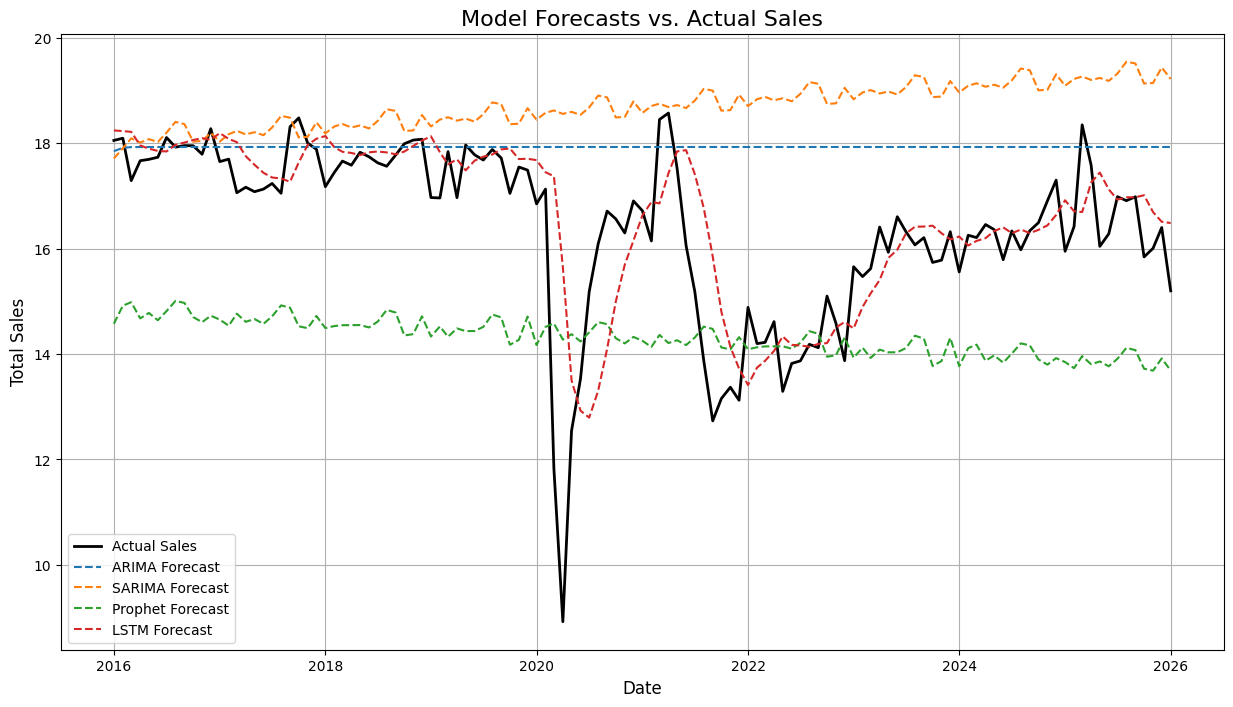

Forecast visualization generated successfully.


In [ ]:
import matplotlib.pyplot as plt

# 1. Create a figure and an axes object for the plot.
plt.figure(figsize=(15, 8))

# 2. Plot the actual_test_data on the axes, labeling it 'Actual Sales'.
plt.plot(actual_test_data, label='Actual Sales', color='black', linewidth=2)

# 3. Iterate through the all_predictions dictionary. For each model:
for model_name, predictions in all_predictions.items():
    # Align predictions with actual data for plotting
    aligned_predictions = predictions.reindex(actual_test_data.index).dropna()
    plt.plot(aligned_predictions, label=f'{model_name} Forecast', linestyle='--')

# 4. Add a title to the plot
plt.title('Model Forecasts vs. Actual Sales', fontsize=16)

# 5. Label the x-axis as 'Date' and the y-axis as 'Total Sales'.
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

# 6. Add a legend to distinguish between the actual data and each model's forecast.
plt.legend(fontsize=10)

# 7. Add grid for better readability
plt.grid(True)

# 8. Display the plot.
plt.show()

print("Forecast visualization generated successfully.")

## Final Task

### Subtask:
Summarize the findings from the model evaluations, discuss the strengths and weaknesses of each forecasting method, and recommend the best-performing model based on the chosen metrics.


## Summary:

### Q&A
*   **Summarize the findings from the model evaluations:** The evaluation of four forecasting models (ARIMA, SARIMA, Prophet, and LSTM) on the `TOTALSA` sales data revealed that the LSTM model demonstrated superior performance across all chosen metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).
*   **Discuss the strengths and weaknesses of each forecasting method:**
    *   **LSTM:**
        *   **Strengths:** Achieved the lowest error rates (MAE of 0.69, RMSE of 1.18, and MAPE of 4.76%), indicating its strong ability to capture complex non-linear patterns and dependencies in the time series.
        *   **Weaknesses:** Requires extensive data preparation (scaling, sequence creation) and more computational resources. Its "black-box" nature makes interpretation of specific drivers challenging.
    *   **ARIMA:**
        *   **Strengths:** Performed relatively well (MAE of 1.59, RMSE of 2.23, MAPE of 10.98%), outperforming SARIMA and Prophet for this dataset. It's a robust statistical method for non-seasonal time series.
        *   **Weaknesses:** Does not explicitly account for seasonality, which was present in the data.
    *   **SARIMA:**
        *   **Strengths:** Designed to explicitly handle seasonal patterns.
        *   **Weaknesses:** Surprisingly performed worse than ARIMA (MAE of 2.31, RMSE of 2.93, MAPE of 15.55%), suggesting the chosen seasonal parameters might not have been optimal or its performance was less robust compared to other models for this specific dataset.
    *   **Prophet:**
        *   **Strengths:** User-friendly, handles missing data well, and automatically detects trends and seasonal components.
        *   **Weaknesses:** Showed moderate performance (MAE of 2.39, RMSE of 2.60, MAPE of 14.39%), being outperformed by LSTM and ARIMA.
*   **Recommend the best-performing model based on the chosen metrics:** Based on its significantly lower MAE, RMSE, and MAPE, the **LSTM model** is recommended as the best-performing model for forecasting `TOTALSA` sales.

### Data Analysis Key Findings
*   Time series decomposition of `TOTALSA` revealed clear trend, seasonal, and residual components.
*   Initial stationarity tests (ADF p-value: 0.043872, KPSS p-value: 0.010000) indicated conflicting results, suggesting trend non-stationarity. First-order differencing was applied, after which both ADF (p-value: 1.285193e-29) and KPSS (p-value: 0.100000) tests confirmed the stationarity of the differenced series.
*   An ARIMA(1,1,1) model was implemented after identifying differencing order `d=1` and `p=1, q=1` from ACF/PACF plots.
*   A SARIMA(1,1,1)(1,1,1,12) model was implemented, incorporating monthly seasonality (S=12).
*   A Prophet model was trained with yearly seasonality enabled for monthly data.
*   An LSTM model was implemented after scaling the data and creating sequences with a `look_back` period of 12. The model consisted of an LSTM layer with 50 units and a Dense output layer.
*   Model evaluation using a held-out test set yielded the following performance metrics:
    *   **LSTM:** MAE: 0.69, RMSE: 1.18, MAPE: 4.76\%
    *   **ARIMA:** MAE: 1.59, RMSE: 2.23, MAPE: 10.98\%
    *   **Prophet:** MAE: 2.39, RMSE: 2.60, MAPE: 14.39\%
    *   **SARIMA:** MAE: 2.31, RMSE: 2.93, MAPE: 15.55\%
*   The LSTM model significantly outperformed all other models across all evaluated metrics.

### Insights or Next Steps
*   The superior performance of the LSTM model suggests that the `TOTALSA` sales data contains complex non-linear patterns that neural networks are better equipped to capture compared to traditional statistical models. Further optimization of the LSTM architecture (e.g., more layers, different units) or hyperparameter tuning could yield even better results.
*   Given the strong seasonal component identified in the decomposition and the relatively weaker performance of SARIMA compared to ARIMA, exploring alternative seasonal parameter combinations for SARIMA or incorporating more explicit seasonality features into the LSTM model could be beneficial.
